<a href="https://colab.research.google.com/github/Durga-Jayakumar/Social-Network-Ads-Purchase-Prediction/blob/main/social_netwoking_ads.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Social Network Ads Purchase Prediction

**Overview**

This project focuses on predicting whether a user will purchase a product based on demographic features such as age, estimated salary, and gender. Using a dataset of social network advertisements, the goal is to build a classification model that can accurately identify potential buyers.

The project begins with data preprocessing, including handling missing values, encoding categorical variables, and feature scaling. A Logistic Regression model is first implemented as a baseline to understand the underlying patterns in the data and establish initial performance.
To improve results, a Random Forest Classifier is then applied, allowing the model to capture more complex, non-linear relationships between features. Model performance is evaluated using metrics such as accuracy, precision, recall, F1-score, and confusion matrix.

The final model demonstrates improved accuracy and a stronger ability to identify buyers, highlighting the importance of selecting appropriate models based on the nature of the data.

**Data Set Information**

This dataset is referred from Kaggle Repository.

Kaggle source: https://www.kaggle.com/datasets/rakeshrau/social-network-ads/data

**Data Card**

  Shape : 400 Rows & 5 Columns

  Attributes :

*   User ID : Unique ID for each user
*   Gender : Male/Female
*   Age : 18 - 60
*   EstimatedSalary : 15.0k - 150k
*   Purchased : 0/1



In [ ]:
#Import required standard libraires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report
)

In [ ]:
#Load data
df = pd.read_csv("Social_Network_Ads.csv")
print("Shape:", df.shape)
print(df.head())

Shape: (400, 5)
    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0


In [ ]:
#Clean data
print(df.isnull().sum())
df = df.drop(columns=["User ID"])

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64


In [ ]:
#Features and target
X = df[["Age", "EstimatedSalary"]].values
y = df["Purchased"].values

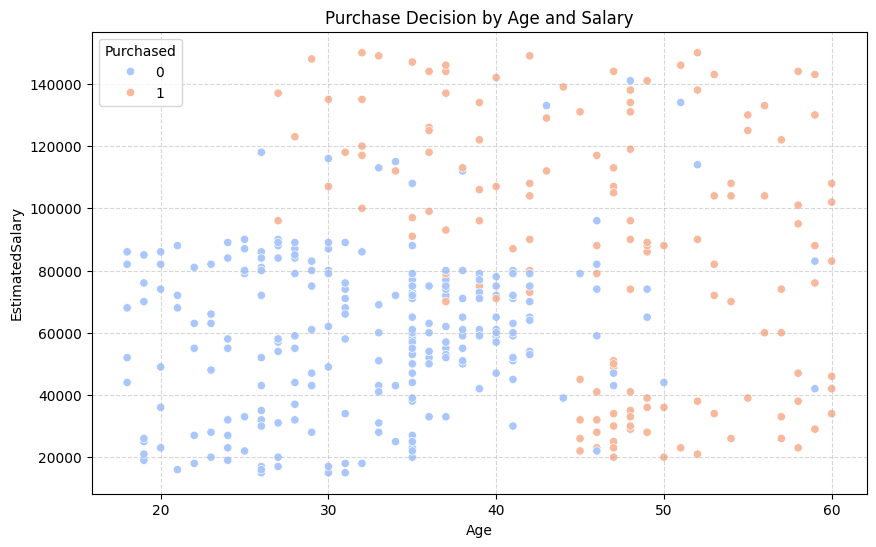

In [ ]:
#Scatter Plot of Age vs. Salary
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='EstimatedSalary', hue='Purchased', palette='coolwarm')

plt.title('Purchase Decision by Age and Salary')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

The data reveals a clear trend: while younger, lower-income individuals predominantly fall into the "Non-Purchase" category, conversion rates increase significantly among older and higher-earning individuals. . The presence of an overlapping "decision zone" in the center of the distribution highlights the limitations of linear classifiers

In [ ]:
#Split test and train data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain size: {len(X_train)} | Test size: {len(X_test)}")


Train size: 320 | Test size: 80


In [ ]:
#Feature scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

##1. Logistic regression
We start with Logistic Regression to establish a baseline. Logistic Regression is a linear classifier that works by drawing a straight decision boundary to separate the classes.

In [ ]:
#Train model
model = LogisticRegression(random_state=42)
model.fit(X_train_sc, y_train)
y_pred = model.predict(X_test_sc)

In [ ]:
#Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {acc:.4f} ({acc*100:.2f}%)")


Test Accuracy: 0.8375 (83.75%)


In [ ]:
#Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Not Bought", "Bought"]))


Classification Report:
              precision    recall  f1-score   support

  Not Bought       0.83      0.94      0.88        51
      Bought       0.86      0.66      0.75        29

    accuracy                           0.84        80
   macro avg       0.85      0.80      0.81        80
weighted avg       0.84      0.84      0.83        80



The Logistic Regression achieved an accuracy of ~84%. However, the Classification Report reveals a significant weakness:

High precision and low Recall for shows that the model is conservative. It's accurate when it predicts a "Buyer", but it misses nearly 34% of actual buyers because they fall into "non-linear" areas of the data that a straight line cannot capture.

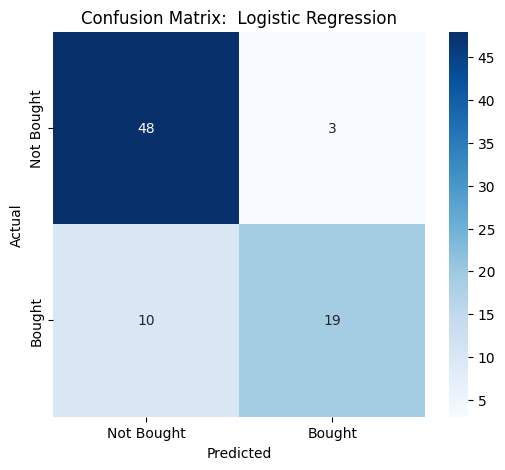

In [ ]:
#Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Not Bought", "Bought"],
    yticklabels=["Not Bought", "Bought"]
)
plt.title("Confusion Matrix:  Logistic Regression")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

Logistic regression performs well when the data is linearly separable. In the confusion matrix, it correctly classifies most instances but makes errors in overlapping regions where the classes are not clearly separable. This results in some false positives and false negatives

##2. Random Forest Classifier

In [ ]:
#Train model
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_split=5, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, min_samples_split=5, random_state=42)

In [ ]:
#Accuracy
test_acc = accuracy_score(y_test, rf_model.predict(X_test))
print(f"Test Accuracy: {test_acc:.2f}")

Test Accuracy: 0.90


In [ ]:
#Classification report
print("\nClassification Report:")
print(classification_report(y_test, rf_model.predict(X_test)))


Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.90      0.92        51
           1       0.84      0.90      0.87        29

    accuracy                           0.90        80
   macro avg       0.89      0.90      0.89        80
weighted avg       0.90      0.90      0.90        80



The logistic regression model achieves an accuracy of 90%, indicating strong overall performance. It performs well across both classes, with high precision for non-buyers (0.94) and strong recall for buyers (0.90), meaning it effectively identifies actual purchase cases. The balanced precision, recall, and F1-scores suggest the model generalizes well and handles both classes reliably.

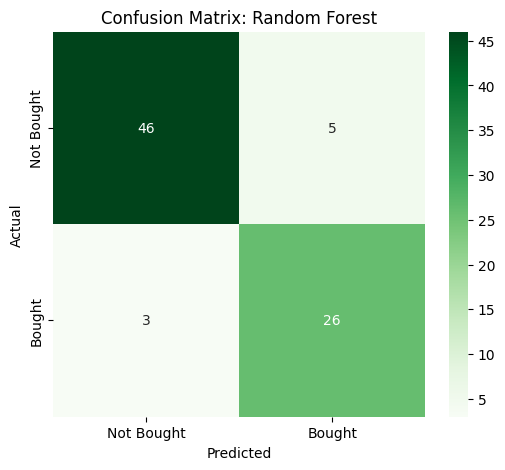

In [ ]:
#Confusion matrix
y_pred_rf = rf_model.predict(X_test)

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_rf, annot=True, fmt="d", cmap="Greens",
    xticklabels=["Not Bought", "Bought"],
    yticklabels=["Not Bought", "Bought"]
)
plt.title("Confusion Matrix: Random Forest")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

Random forest is a more flexible model that can capture non-linear relationships in the data. Its confusion matrix typically shows fewer misclassifications compared to logistic regression, as it can better handle complex decision boundaries.

##Analysis and Key Takeaways
1. Linear vs. Non-Linear Patterns

      The primary finding of this project is that consumer behavior in this dataset is non-linear. While Logistic Regression provided a decent baseline (84% accuracy), it was limited by its mathematical nature as a linear classifier. It could only separate buyers from non-buyers with a single straight line, causing it to miss younger, high-earning users who bought.

2. Use of Random Forest Classifier

    By transitioning to a Random Forest Classifier, multiple decision trees were used to create a more flexible boundary. This moved our recall for Buyers from 0.66 to 0.90, meaning the model became significantly better at identifying potential customers.

3. Business Impact


    From a marketing perspective, the Random Forest model is the superior choice.
     
    High Precision (0.84): Minimizes "ad waste" by correctly identifying those likely to buy.

    High Recall (0.90): Minimizes "missed opportunities" by capturing the vast majority of the target audience.

## Conclusion
The project improved from a Logistic Regression baseline (84% accuracy) to a tuned Random Forest model with 90% accuracy. Logistic regression struggled with overlapping data, while Random Forest handled these patterns better using non-linear decision boundaries. This led to a significant improvement in identifying buyers.